# NB13d: Consolidated Results Report (v3)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Pipeline position: NB06-NB09 → **NB11d** (→ NB10/NB11/NB12 future)

**Purpose:** Single notebook that loads ALL results from the BDA ML pipeline
via `bda_results.ResultRegistry`. Every experiment is traced to its source
notebook, parquet/dataset, tier selection, feature set, classifier, CV method,
and full metric suite.

**Requires:** `bda_results.py` in NOTEBOOKS_DIR (installed by this notebook if missing).

**What gets tracked per experiment:**
- Data: parquet name + fmt + path, tier_selection, cities list, n_buildings, n_damaged, damage_rate
- Features: feature_set_name, feature_cols list, n_features, feature_groups
- Method: classifier_name + params, cv_method, n_folds, imputation, scaling, class_weight
- Metrics: AUC, F1, precision, recall, accuracy, balanced_accuracy, MCC, avg_precision, log_loss, brier, specificity, TP/FP/TN/FN, precision@recall_80/90/95
- Folds: per-fold AUCs, mean/std/min/max
- Per-city: full metrics per city
- Feature stats: mean/std/skewness/kurtosis/nan_pct per feature per parquet
- Provenance: timestamp, run_id, notebook, cell_id, notes, tags

**Cell structure:**
| Cell | Name | What |
|------|------|------|
| 1 | CONFIG | Tier selection, global_setup |
| 2 | LOAD REGISTRY | Load all experiments + profiles from registry/ |
| 3 | EXPERIMENTS TABLE | Full comparison table with all metrics |
| 4 | PER-NOTEBOOK SUMMARY | Best per notebook, per parquet, per classifier |
| 5 | PER-CITY BREAKDOWN | Which cities are hard/easy, per experiment |
| 6 | DATASET PROFILES | Parquet statistics, NaN rates, feature distributions |
| 7 | FEATURE ANALYSIS | Top features by AUC, skewness, NaN, per parquet |
| 8 | COMPARISON PLOTS | Bar charts, heatmaps, scatter |
| 9 | REGRESSION DETECTIVE | Compare runs over time, find when results degraded |
| 10 | GAP ANALYSIS | Missing results, known bugs, future notebooks |
| 11 | INTEGRATION EXAMPLES | How to add bda_results to existing notebooks |
| 12 | SAVE REPORT | Consolidated CSV + JSON to disk |

In [1]:
# @title CELL 1: NB11d CONFIG + GLOBAL SETUP
TIER_SELECTION = [0, 1, 2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

OUT_DIR = RESULTS_ROOT / 'nb11d'
OUT_DIR.mkdir(parents=True, exist_ok=True)

from datetime import datetime as _dt
import pandas as pd
import numpy as np
import json as _json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# --- display options: show full DataFrames in Jupyter -----------------
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

import sys
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from bda_results import ResultRegistry

print(f"  OUT_DIR:        {OUT_DIR}")
print(f"  REGISTRY_DIR:   {RESULTS_ROOT / 'registry'}")
print(f"  TIER_SELECTION: {TIER_SELECTION}")


BDA GLOBAL SETUP
Started: 2026-07-03 08:43:52
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     930.7/7452.0 GB (6521.3 GB free)
  GDrive (F:)     1405.7/3726.0 GB (2320.3 GB free)
  Local data      11563.4/14901.9 GB (3338.4 GB free)
  Data stack      1405.7/3726.0 GB (2320.3 GB free)
  WSL ext4        69.1/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

In [2]:
# @title CELL 2: LOAD ALL REGISTRY DATA

print("=" * 70)
print("CELL 2: LOAD REGISTRY")
print("=" * 70)

experiments, profiles = ResultRegistry.load_all(RESULTS_ROOT)

EXPERIMENTS_DF = ResultRegistry.experiments_to_dataframe(experiments)
PROFILES_DF = ResultRegistry.profiles_to_dataframe(profiles)
FEATURE_STATS_DF = ResultRegistry.feature_stats_to_dataframe(profiles)
PER_CITY_DF = ResultRegistry.per_city_to_dataframe(experiments)

# also keep raw experiments for per-city deep dives
RAW_EXPERIMENTS = experiments
RAW_PROFILES = profiles

# --- tag xBD-only experiments -----------------------------------------
# xBD experiments: trained+tested on xBD cities (not Ukrainian tiers).
# Detection: experiment_name or parquet_name contains "xbd" (case-insensitive),
# OR the experiment cities have zero overlap with our Ukrainian city set.
CITIES_TO_PROCESS, _ = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_SELECTION] if isinstance(CITY_SELECTION, str) else CITY_SELECTION,
    require_unosat=REQUIRE_UNOSAT,
)
UA_CITIES = set(CITIES_TO_PROCESS)

if len(EXPERIMENTS_DF) > 0:
    def _is_xbd(row):
        name = str(row.get("experiment_name", "")).lower()
        pq   = str(row.get("parquet_name", "")).lower()
        tags = str(row.get("tags", "")).lower()
        nb   = str(row.get("notebook", "")).lower()
        if "xbd" in name or "xbd" in pq or "xbd" in tags:
            return True
        # check if cities column exists and has zero overlap with UA
        cities_raw = row.get("cities", None)
        if cities_raw and isinstance(cities_raw, (list, str)):
            if isinstance(cities_raw, str):
                city_set = set(c.strip() for c in cities_raw.split(","))
            else:
                city_set = set(cities_raw)
            if len(city_set) > 0 and len(city_set & UA_CITIES) == 0:
                return True
        return False
    EXPERIMENTS_DF["is_xbd"] = EXPERIMENTS_DF.apply(_is_xbd, axis=1)
else:
    EXPERIMENTS_DF["is_xbd"] = pd.Series(dtype=bool)

if len(PER_CITY_DF) > 0:
    xbd_exp_names = set(EXPERIMENTS_DF.loc[EXPERIMENTS_DF["is_xbd"], "experiment_name"])
    PER_CITY_DF["is_xbd"] = PER_CITY_DF["experiment_name"].isin(xbd_exp_names)

n_total = len(EXPERIMENTS_DF)
n_xbd = int(EXPERIMENTS_DF["is_xbd"].sum()) if len(EXPERIMENTS_DF) > 0 else 0
n_ua  = n_total - n_xbd

print(f"\n  EXPERIMENTS_DF:    {n_total} total  ({n_ua} Ukraine, {n_xbd} xBD-only)")
print(f"  PROFILES_DF:      {len(PROFILES_DF)} rows")
print(f"  FEATURE_STATS_DF: {len(FEATURE_STATS_DF)} rows")
print(f"  PER_CITY_DF:      {len(PER_CITY_DF)} rows")

if n_total == 0:
    print("\n  WARNING: No experiments found in registry.")
    print("  Run NB06-NB09 notebooks first (with bda_results integration).")
    print("  Or see CELL 11 for integration examples.")


CELL 2: LOAD REGISTRY
  Loaded: NB11_V2_experiments_20260703_083441.json (62 experiments, notebook=NB11_V2)
  Loaded: NB09b_experiments_20260628_003554.json (40 experiments, notebook=NB09b)
  Loaded: NB09c_v2_experiments_20260614_180054.json (74 experiments, notebook=NB09c_v2)
  Loaded: NB09d_experiments_20260621_232712.json (14 experiments, notebook=NB09d)
  Loaded: NB10a_v1_experiments_20260507_234428.json (6 experiments, notebook=NB10a_v1)
  Loaded: NB09aV3_v1_experiments_20260506_142934.json (47 experiments, notebook=NB09aV3_v1)
  Loaded: NB09aV5_v1_experiments_20260503_220957.json (47 experiments, notebook=NB09aV5_v1)
  Loaded: NB09aV4_v1_experiments_20260503_180614.json (47 experiments, notebook=NB09aV4_v1)
  Loaded: NB09a_v2_experiments_20260501_164920.json (44 experiments, notebook=NB09a_v2)
  Loaded: NB09eV3_v1_experiments_20260429_174010.json (18 experiments, notebook=NB09eV3_v1)
  Loaded: NB09cV3_v1_experiments_20260429_090246.json (48 experiments, notebook=NB09cV3_v1)
  Loa

In [3]:
# @title CELL 3: UKRAINE EXPERIMENTS TABLE

print("=" * 70)
print("CELL 3: UKRAINE EXPERIMENTS (xBD excluded, see Cell 3b)")
print("=" * 70)

if len(EXPERIMENTS_DF) == 0:
    print("  No experiments. Skipping.")
else:
    ua_df = EXPERIMENTS_DF[~EXPERIMENTS_DF["is_xbd"]].copy()
    print(f"\n  {len(ua_df)} Ukraine experiments (excluding {n_xbd} xBD-only)\n")

    metric_cols = ["auc", "f1", "precision", "recall", "mcc",
                   "balanced_accuracy", "average_precision",
                   "specificity", "brier_score",
                   "precision_at_recall_90",
                   "auc_mean", "auc_std"]
    metric_cols = [c for c in metric_cols if c in ua_df.columns]

    id_cols = ["experiment_name", "notebook", "cell_id",
               "parquet_name", "classifier_name", "feature_set_name",
               "cv_method", "n_folds", "imputation",
               "n_features", "n_cities", "n_buildings",
               "n_damaged", "damage_rate"]
    id_cols = [c for c in id_cols if c in ua_df.columns]

    display_df = ua_df[id_cols + metric_cols].sort_values("auc", ascending=False)
    display(display_df)

    if "auc" in ua_df.columns and ua_df["auc"].notna().any():
        best = ua_df.loc[ua_df["auc"].idxmax()]
        worst_real = ua_df[(ua_df["auc"].notna()) & (ua_df["is_reference"] != True)].sort_values("auc").head(1)
        print(f"\n  BEST:  {best['experiment_name']} -> AUC={best['auc']:.4f} ({best['notebook']}, {best['parquet_name']}, {best['classifier_name']})")
        if len(worst_real) > 0:
            w = worst_real.iloc[0]
            print(f"  WORST: {w['experiment_name']} -> AUC={w['auc']:.4f} ({w['notebook']}, {w['parquet_name']}, {w['classifier_name']})")


CELL 3: UKRAINE EXPERIMENTS (xBD excluded, see Cell 3b)

  745 Ukraine experiments (excluding 23 xBD-only)



,experiment_name,notebook,cell_id,parquet_name,classifier_name,feature_set_name,cv_method,n_folds,imputation,n_features,n_cities,n_buildings,n_damaged,damage_rate,auc,f1,precision,recall,mcc,balanced_accuracy,average_precision,specificity,brier_score,precision_at_recall_90,auc_mean,auc_std
1,Ballinger_2024_PWTT,reference,,,,,GroupKFold,NaN,median,1,0,NaN,NaN,NaN,0.8700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NB11e_dietrich28__block_stats__LightGBM,NB11_V2,NB11e_dietrich28__block_stats__LightGBM,bda_block_stats_v2,LightGBM-Optuna,dietrich28,GroupKFold,5.0000,median,56,21,598595.0000,7332.0000,0.0122,0.8652,0.0802,0.0423,0.7900,0.1487,0.7840,0.1038,0.7779,0.1493,0.0286,0.7451,0.0732
3,NB11e_dietrich28__block_stats__XGBoost,NB11_V2,NB11e_dietrich28__block_stats__XGBoost,bda_block_stats_v2,XGBoost-Optuna,dietrich28,GroupKFold,5.0000,median,56,21,598595.0000,7332.0000,0.0122,0.8565,0.0049,0.2368,0.0025,0.0230,0.5012,0.0940,0.9999,0.0117,0.0268,0.7443,0.0743
4,NB11b_A15_block_stats__block_stats__LightGBM-MIA,NB11_V2,NB11b_A15_block_stats__block_stats__LightGBM-MIA,bda_block_stats_v2,LightGBM-MIA-Optuna,None,GroupKFold,5.0000,native_nan,780,21,598595.0000,7332.0000,0.0122,0.8531,0.0805,0.0424,0.8091,0.1513,0.7912,0.0708,0.7733,0.1837,0.0272,0.6434,0.1473
5,NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA,NB11_V2,NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA,bda_fusion_ms_cohdrop_v2,LightGBM-MIA-Optuna,None,GroupKFold,5.0000,native_nan,88,18,466704.0000,6755.0000,0.0145,0.8514,0.0898,0.0475,0.8161,0.1592,0.7880,0.0746,0.7598,0.1986,0.0342,0.7331,0.0488
6,NB11b_A16_A17_A18_rolling__rolling_stats_roll7__LightGBM...,NB11_V2,NB11b_A16_A17_A18_rolling__rolling_stats_roll7__LightGBM...,bda_rolling_stats_roll7_v2,LightGBM-MIA-Optuna,None,GroupKFold,5.0000,native_nan,57,21,598595.0000,7332.0000,0.0122,0.8514,0.0807,0.0425,0.8044,0.1510,0.7898,0.0695,0.7751,0.1854,0.0268,0.6570,0.1496
7,NB11a_F2_F6__fusion_indices_card_cohdrop__LightGBM-MIA,NB11_V2,NB11a_F2_F6__fusion_indices_card_cohdrop__LightGBM-MIA,bda_fusion_indices_card_cohdrop_v2,LightGBM-MIA-Optuna,None,GroupKFold,5.0000,native_nan,86,18,466704.0000,6755.0000,0.0145,0.8471,0.0891,0.0471,0.8164,0.1581,0.7870,0.0742,0.7575,0.1986,0.0337,0.7481,0.0443
8,NB11a_F3__fusion_card_cohdrop__LightGBM-MIA,NB11_V2,NB11a_F3__fusion_card_cohdrop__LightGBM-MIA,bda_fusion_card_cohdrop_v2,LightGBM-MIA-Optuna,None,GroupKFold,5.0000,native_nan,32,20,584986.0000,6901.0000,0.0118,0.8457,0.0804,0.0423,0.8184,0.1536,0.7985,0.0462,0.7787,0.1575,0.0313,0.7242,0.0693
9,NB11e_dietrich28__block_stats__RF-200,NB11_V2,NB11e_dietrich28__block_stats__RF-200,bda_block_stats_v2,RF-200-Optuna,dietrich28,GroupKFold,5.0000,median,56,21,598595.0000,7332.0000,0.0122,0.8452,0.0837,0.0444,0.7234,0.1461,0.7653,0.0979,0.8071,0.1605,0.0227,0.7326,0.0898
10,NB11a_F4_F7__fusion_composite_cohdrop__LightGBM-MIA,NB11_V2,NB11a_F4_F7__fusion_composite_cohdrop__LightGBM-MIA,bda_fusion_composite_cohdrop_v2,LightGBM-MIA-Optuna,None,GroupKFold,5.0000,native_nan,145,18,466704.0000,6755.0000,0.0145,0.8449,0.0904,0.0479,0.8150,0.1599,0.7885,0.0745,0.7620,0.1979,0.0297,0.6783,0.1052



  BEST:  Ballinger_2024_PWTT -> AUC=0.8700 (reference, , )
  WORST: plausibility_standalone_coh_drop -> AUC=0.1908 (NB09e_v2, bda_plausibility_v2, signal_coh_drop)


# CELL 3b: xBD-ONLY REFERENCE
Experiments trained and tested exclusively on xBD data (non-Ukrainian cities).
Shown as reference ceiling, not mixed into Ukraine results.


In [4]:
# @title CELL 3b: xBD-ONLY REFERENCE

print("=" * 70)
print("CELL 3b: xBD-ONLY EXPERIMENTS (reference ceiling)")
print("=" * 70)

if len(EXPERIMENTS_DF) == 0 or n_xbd == 0:
    print("  No xBD-only experiments found.")
else:
    xbd_df = EXPERIMENTS_DF[EXPERIMENTS_DF["is_xbd"]].copy()
    ref_cols = ["experiment_name", "notebook", "parquet_name",
               "classifier_name", "auc", "f1", "n_buildings"]
    ref_cols = [c for c in ref_cols if c in xbd_df.columns]
    xbd_display = xbd_df[ref_cols].sort_values("auc", ascending=False)
    display(xbd_display)

    if xbd_df["auc"].notna().any():
        best_xbd = xbd_df.loc[xbd_df["auc"].idxmax()]
        print(f"\n  xBD ceiling: AUC={best_xbd['auc']:.4f}  ({best_xbd['experiment_name']})")
        print(f"  This is the clean-supervision upper bound (labels are complete, imagery is VHR).")


CELL 3b: xBD-ONLY EXPERIMENTS (reference ceiling)


,experiment_name,notebook,parquet_name,classifier_name,auc,f1,n_buildings
0,xbd_on_xbd,NB09d,pixel_segmentation,U-Net,0.9643,NaN,NaN
161,xBD__RGB__LightGBM,NB08b,xBD,LightGBM,0.6770,0.5140,70931.0000
173,xBD__RGB__ExtraTrees,NB08b,xBD,ExtraTrees,0.6688,0.4772,70931.0000
196,xBD__RGB__UISEM_voting,NB08b,xBD,UISEM_voting,0.6602,0.4162,70931.0000
197,xBD__RGB__RF-200,NB08b,xBD,RF-200,0.6592,0.4325,70931.0000
226,xBD__RGB__GBM,NB08b,xBD,GBM,0.6528,0.4016,70931.0000
230,xBD__RGB__XGBoost,NB08b,xBD,XGBoost,0.6524,0.4088,70931.0000
274,xBD__RGB__AdaBoost,NB08b,xBD,AdaBoost,0.6435,0.0773,70931.0000
315,xBD__RGB__LogReg,NB08b,xBD,LogReg,0.6316,0.4798,70931.0000
345,BRIGHT__all__LogReg,NB08b,BRIGHT,LogReg,0.6251,0.3362,92423.0000



  xBD ceiling: AUC=0.9643  (xbd_on_xbd)
  This is the clean-supervision upper bound (labels are complete, imagery is VHR).


In [5]:
# @title CELL 4: PER-NOTEBOOK / PER-PARQUET / PER-CLASSIFIER SUMMARY
print("=" * 70)
print("CELL 4: SUMMARY BREAKDOWNS (Ukraine only)")
print("=" * 70)
if len(EXPERIMENTS_DF) == 0:
    print("  No experiments. Skipping.")
else:
    if "is_reference" in EXPERIMENTS_DF.columns:
        non_ref = EXPERIMENTS_DF[
            (~EXPERIMENTS_DF["is_reference"].fillna(False).astype(bool)) &
            (~EXPERIMENTS_DF["is_xbd"])
        ].copy()
    else:
        non_ref = EXPERIMENTS_DF[~EXPERIMENTS_DF["is_xbd"]].copy()

    # --- best per notebook ---
    print("\n  BEST PER NOTEBOOK:")
    rows_nb = []
    for nb in sorted(non_ref["notebook"].dropna().unique()):
        nb_df = non_ref[non_ref["notebook"] == nb]
        if nb_df["auc"].notna().any():
            best = nb_df.loc[nb_df["auc"].idxmax()]
            rows_nb.append({"notebook": nb, "auc": best["auc"],
                            "f1": best.get("f1", np.nan),
                            "experiment": best["experiment_name"],
                            "classifier": best["classifier_name"],
                            "features": best["feature_set_name"],
                            "parquet": best["parquet_name"]})
    if rows_nb:
        display(pd.DataFrame(rows_nb).sort_values("auc", ascending=False))

    # --- best per parquet ---
    print("\n  BEST PER PARQUET:")
    rows_pq = []
    for pq in sorted(non_ref["parquet_name"].dropna().unique()):
        pq_df = non_ref[non_ref["parquet_name"] == pq]
        if pq_df["auc"].notna().any():
            best = pq_df.loc[pq_df["auc"].idxmax()]
            rows_pq.append({"parquet": pq, "auc": best["auc"],
                            "experiment": best["experiment_name"],
                            "notebook": best["notebook"]})
    if rows_pq:
        display(pd.DataFrame(rows_pq).sort_values("auc", ascending=False))

    # --- best per classifier ---
    print("\n  BEST PER CLASSIFIER:")
    rows_clf = []
    for clf in sorted(non_ref["classifier_name"].dropna().unique()):
        clf_df = non_ref[non_ref["classifier_name"] == clf]
        if clf_df["auc"].notna().any():
            best = clf_df.loc[clf_df["auc"].idxmax()]
            rows_clf.append({"classifier": clf, "auc": best["auc"],
                             "experiment": best["experiment_name"],
                             "parquet": best["parquet_name"]})
    if rows_clf:
        display(pd.DataFrame(rows_clf).sort_values("auc", ascending=False))

    # --- best per feature set ---
    print("\n  BEST PER FEATURE SET:")
    rows_fs = []
    for fs in sorted(non_ref["feature_set_name"].dropna().unique()):
        if not fs:
            continue
        fs_df = non_ref[non_ref["feature_set_name"] == fs]
        if fs_df["auc"].notna().any():
            best = fs_df.loc[fs_df["auc"].idxmax()]
            rows_fs.append({"feature_set": fs, "auc": best["auc"],
                            "n_features": best["n_features"],
                            "classifier": best["classifier_name"],
                            "parquet": best["parquet_name"]})
    if rows_fs:
        display(pd.DataFrame(rows_fs).sort_values("auc", ascending=False))

    # --- cross-tab: parquet x classifier ---
    print("\n  PARQUET x CLASSIFIER AUC MATRIX:")
    if len(non_ref) > 5:
        pivot = non_ref.pivot_table(values="auc", index="parquet_name",
                                     columns="classifier_name", aggfunc="max")
        if len(pivot) > 0:
            display(pivot.style.format("{:.3f}", na_rep="-").background_gradient(
                cmap="RdYlGn", vmin=0.4, vmax=0.85))


CELL 4: SUMMARY BREAKDOWNS (Ukraine only)

  BEST PER NOTEBOOK:


,notebook,auc,f1,experiment,classifier,features,parquet
19,NB11_V2,0.8652,0.0802,NB11e_dietrich28__block_stats__LightGBM,LightGBM-Optuna,dietrich28,bda_block_stats_v2
1,NB08c_v2,0.8417,0.0832,C_F3_fusion_card_cohdrop,LightGBM-300-MIA,manifest_default_minus_leakage,bda_fusion_card_cohdrop_v2
10,NB09a_v2,0.8303,0.0198,R5_XGBoost_dietrich28,XGBoost,dietrich28,bda_block_stats_v2
14,NB09c_v2,0.7826,0.0349,E7c_HistGBM_imputed,HistGBM,all_multimodal,bda_fusion_composite_blockstats_v2
0,NB08b,0.7506,0.0533,BDA__RGB+CARD__LogReg,LogReg,RGB+CARD,BDA
17,NB09e_v2,0.7137,0.0242,L4b_accumulator_s2__date_first_exceedance_mean,signal_s2__date_first_exceedance_mean,s2__date_first_exceedance_mean,bda_ms_maha_v2
11,NB09b,0.7136,0.0810,B2_CCD_approx_coh0,unsupervised_ccd,coh_change_approx_coh0,bda_product_prepost
8,NB09aV4_v1,0.6879,0.0208,R5_ExtraTrees_all_multimodal,ExtraTrees,all_multimodal,bda_fusion_composite_blockstats_v2
3,NB08c_v4,0.6792,0.3234,C_A9_composite_prepost_bands,LightGBM-300-MIA,manifest_default_minus_leakage,bda_composite_prepost_bands_v4
2,NB08c_v3,0.6782,0.3180,C_F4_fusion_ms_cohdrop,LightGBM-300-MIA,manifest_default_minus_leakage,bda_fusion_ms_cohdrop_v3



  BEST PER PARQUET:


,parquet,auc,experiment,notebook
21,bda_block_stats_v2,0.8652,NB11e_dietrich28__block_stats__LightGBM,NB11_V2
100,bda_fusion_ms_cohdrop_v2,0.8514,NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA,NB11_V2
174,bda_rolling_stats_roll7_v2,0.8514,NB11b_A16_A17_A18_rolling__rolling_stats_roll7__LightGBM...,NB11_V2
76,bda_fusion_indices_card_cohdrop_v2,0.8471,NB11a_F2_F6__fusion_indices_card_cohdrop__LightGBM-MIA,NB11_V2
58,bda_fusion_card_cohdrop_v2,0.8457,NB11a_F3__fusion_card_cohdrop__LightGBM-MIA,NB11_V2
70,bda_fusion_composite_cohdrop_v2,0.8449,NB11a_F4_F7__fusion_composite_cohdrop__LightGBM-MIA,NB11_V2
106,bda_lu_change_v2,0.8430,NB11c_A22_lu_change__lu_change__LightGBM-MIA,NB11_V2
64,bda_fusion_composite_blockstats_v2,0.8409,NB11a_F8__fusion_composite_blockstats__LightGBM-MIA,NB11_V2
88,bda_fusion_ms_card_cohdrop_v2,0.8391,NB11a_F2_F6__fusion_ms_card_cohdrop__LightGBM-MIA,NB11_V2
162,bda_rolling_stats_roll13_v2,0.8323,NB11b_A16_A17_A18_rolling__rolling_stats_roll13__LightGB...,NB11_V2



  BEST PER CLASSIFIER:


,classifier,auc,experiment,parquet
19,LightGBM-Optuna,0.8652,NB11e_dietrich28__block_stats__LightGBM,bda_block_stats_v2
42,XGBoost-Optuna,0.8565,NB11e_dietrich28__block_stats__XGBoost,bda_block_stats_v2
18,LightGBM-MIA-Optuna,0.8531,NB11b_A15_block_stats__block_stats__LightGBM-MIA,bda_block_stats_v2
29,RF-200-Optuna,0.8452,NB11e_dietrich28__block_stats__RF-200,bda_block_stats_v2
2,ExtraTrees-Optuna,0.8422,NB11e_dietrich28__block_stats__ExtraTrees,bda_block_stats_v2
17,LightGBM-MIA,0.8417,NB11a_F3__fusion_card_cohdrop__LightGBM-MIA__baseline,bda_fusion_card_cohdrop_v2
16,LightGBM-300-MIA,0.8417,C_F3_fusion_card_cohdrop,bda_fusion_card_cohdrop_v2
41,XGBoost,0.8303,NB11e_dietrich28__block_stats__XGBoost__baseline,bda_block_stats_v2
15,LightGBM,0.8162,R5_LightGBM_dietrich28,bda_block_stats_v2
1,ExtraTrees,0.8112,NB11e_dietrich28__block_stats__ExtraTrees__baseline,bda_block_stats_v2



  BEST PER FEATURE SET:


,feature_set,auc,n_features,classifier,parquet
47,dietrich28,0.8652,56,LightGBM-Optuna,bda_block_stats_v2
14,None,0.8531,780,LightGBM-MIA-Optuna,bda_block_stats_v2
51,manifest_default_minus_leakage,0.8417,0,LightGBM-300-MIA,bda_fusion_card_cohdrop_v2
19,all_multimodal,0.8131,915,LightGBM-Optuna,bda_fusion_composite_blockstats_v2
25,card_block_stats_A15,0.7824,780,RF-200,bda_block_stats_v2
55,ms_plus_blocks_F8,0.7737,915,RF-200,bda_fusion_composite_blockstats_v2
56,ms_plus_cohdrop_F7,0.7720,145,RF-200,bda_fusion_composite_cohdrop_v2
54,ms_only_A9,0.7612,135,RF-200,bda_composite_prepost_bands_v2
16,RGB+CARD,0.7506,31,LogReg,BDA
15,RGB,0.7503,19,ExtraTrees,BDA



  PARQUET x CLASSIFIER AUC MATRIX:


In [6]:
# @title CELL 5: PER-CITY BREAKDOWN (Ukraine only)

print("=" * 70)
print("CELL 5: PER-CITY BREAKDOWN (Ukraine only)")
print("=" * 70)

if len(PER_CITY_DF) == 0:
    print("  No per-city metrics available.")
    print("  (per-city metrics are computed when y_true/y_proba/groups are passed to log_experiment)")
else:
    ua_per_city = PER_CITY_DF[~PER_CITY_DF["is_xbd"]].copy() if "is_xbd" in PER_CITY_DF.columns else PER_CITY_DF.copy()

    if "auc" in ua_per_city.columns and len(ua_per_city) > 0:
        pivot_city = ua_per_city.pivot_table(values="auc", index="city",
                                              columns="experiment_name", aggfunc="first")
        print(f"\n  City x Experiment AUC matrix ({len(pivot_city)} cities):\n")
        display(pivot_city.style.format("{:.3f}", na_rep="-").background_gradient(
            cmap="RdYlGn", axis=None, vmin=0.4, vmax=0.85))

        # mean AUC per city
        city_mean_auc = ua_per_city.groupby("city")["auc"].agg(["mean", "count"]).round(3)
        city_mean_auc.columns = ["mean_auc", "n_experiments"]
        city_mean_auc = city_mean_auc.sort_values("mean_auc")
        print(f"\n  Mean AUC per city (across Ukraine experiments):")
        display(city_mean_auc)

    # per-city damage rates
    city_damage = ua_per_city.groupby("city").agg(
        n_positive=("n_positive", "first"),
        n_negative=("n_negative", "first"),
        prevalence=("prevalence", "first"),
    ).dropna()
    if len(city_damage) > 0:
        city_damage["n_total"] = (city_damage["n_positive"] + city_damage["n_negative"]).astype(int)
        city_damage["n_positive"] = city_damage["n_positive"].astype(int)
        city_damage = city_damage.sort_values("prevalence", ascending=False)
        print(f"\n  Damage rates per city:")
        display(city_damage)


CELL 5: PER-CITY BREAKDOWN (Ukraine only)

  City x Experiment AUC matrix (21 cities):




  Mean AUC per city (across Ukraine experiments):


,mean_auc,n_experiments
city,,
Volnovakha,0.5030,664
Trostianets,0.5120,561
Mykolaiv,0.5190,238
Borodyanka,0.5400,311
Moschun,0.5410,664
Rubizhne,0.5420,496
Chernihiv,0.5480,572
Makariv,0.5580,561
Okhtyrka,0.5700,664



  Damage rates per city:


,n_positive,n_negative,prevalence,n_total
city,,,,
Mariupol,3055,25918.0000,0.1054,28973
Sievierodonetsk,534,8531.0000,0.0589,9065
Moschun,73,1175.0000,0.0585,1248
Rubizhne,431,13178.0000,0.0317,13609
Hostomel,511,18634.0000,0.0267,19145
Lysychansk,1071,40529.0000,0.0257,41600
Irpin,249,17116.0000,0.0143,17365
Volnovakha,163,13300.0000,0.0121,13463
Borodyanka,62,5178.0000,0.0118,5240


In [7]:
# @title CELL 6: DATASET PROFILES

print("=" * 70)
print("CELL 6: DATASET PROFILES")
print("=" * 70)

if len(PROFILES_DF) == 0:
    print("  No dataset profiles available.")
    print("  (profiles are created when log_dataset_profile() is called in notebooks)")
else:
    print(f"\n  {len(PROFILES_DF)} parquets profiled:\n")
    display(PROFILES_DF)

    for prof in RAW_PROFILES:
        pq = prof.get("parquet_name", "?")
        print(f"\n  --- {pq} ---")
        print(f"    rows={prof.get('n_rows')}, features={prof.get('n_features')}, "
              f"cities={prof.get('n_cities')}, NaN={prof.get('nan_rate_overall', 0)*100:.1f}%")
        if "buildings_per_city" in prof:
            city_rows = []
            for city, n in sorted(prof["buildings_per_city"].items(), key=lambda x: -x[1]):
                dr = prof.get("damage_rate_per_city", {}).get(city)
                nan_c = prof.get("nan_rate_per_city", {}).get(city)
                city_rows.append({"city": city, "n_buildings": n,
                                  "damage_rate": dr, "nan_rate": nan_c})
            display(pd.DataFrame(city_rows))


CELL 6: DATASET PROFILES
  No dataset profiles available.
  (profiles are created when log_dataset_profile() is called in notebooks)


In [8]:
# @title CELL 7: FEATURE ANALYSIS (per parquet)

print("=" * 70)
print("CELL 7: FEATURE ANALYSIS")
print("=" * 70)

if len(FEATURE_STATS_DF) == 0:
    print("  No feature stats available.")
else:
    for pq in sorted(FEATURE_STATS_DF["parquet_name"].unique()):
        pq_df = FEATURE_STATS_DF[FEATURE_STATS_DF["parquet_name"] == pq].copy()
        print(f"\n  === {pq} ({len(pq_df)} features) ===")

        print(f"    NaN: mean={pq_df['nan_pct'].mean():.1f}%, "
              f"max={pq_df['nan_pct'].max():.1f}%, "
              f"n_all_nan={int((pq_df['nan_pct'] >= 99.9).sum())}")
        if "skewness" in pq_df.columns:
            print(f"    Skewness: mean|skew|={pq_df['skewness'].abs().mean():.2f}, "
                  f"n_highly_skewed(>2)={int((pq_df['skewness'].abs() > 2).sum())}")
        if "kurtosis" in pq_df.columns:
            print(f"    Kurtosis: mean|kurt|={pq_df['kurtosis'].abs().mean():.2f}, "
                  f"n_heavy_tailed(>7)={int((pq_df['kurtosis'].abs() > 7).sum())}")

        # top features by CV
        if "cv" in pq_df.columns:
            print(f"\n    Top 5 by coefficient of variation:")
            display(pq_df.nlargest(5, "cv")[["feature", "cv", "mean", "std"]])

        # most NaN-heavy features
        high_nan = pq_df[pq_df["nan_pct"] > 50].sort_values("nan_pct", ascending=False)
        if len(high_nan) > 0:
            print(f"\n    Features with >50% NaN ({len(high_nan)}):")
            display(high_nan[["feature", "nan_pct"]].head(10))

        # constant features
        if "std" in pq_df.columns:
            zero_var = pq_df[pq_df["std"] < 1e-10]
            if len(zero_var) > 0:
                print(f"    CONSTANT FEATURES ({len(zero_var)}): {list(zero_var['feature'][:5])}")


CELL 7: FEATURE ANALYSIS
  No feature stats available.


CELL 8: COMPARISON PLOTS (Ukraine only)


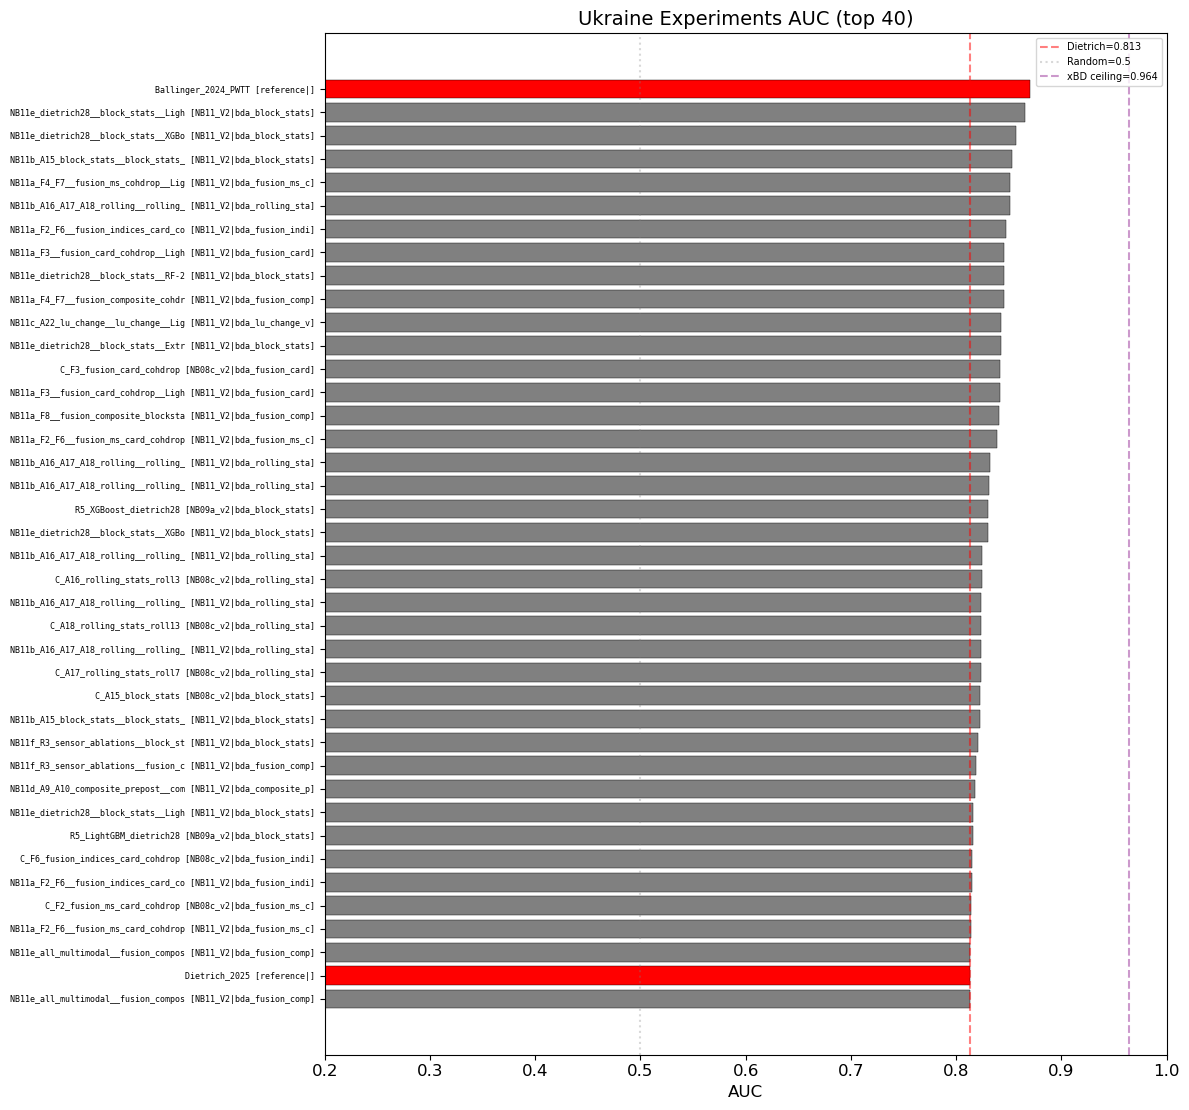

  Plot: ua_experiments_auc_bar.png


  Plot: parquet_classifier_heatmap.png


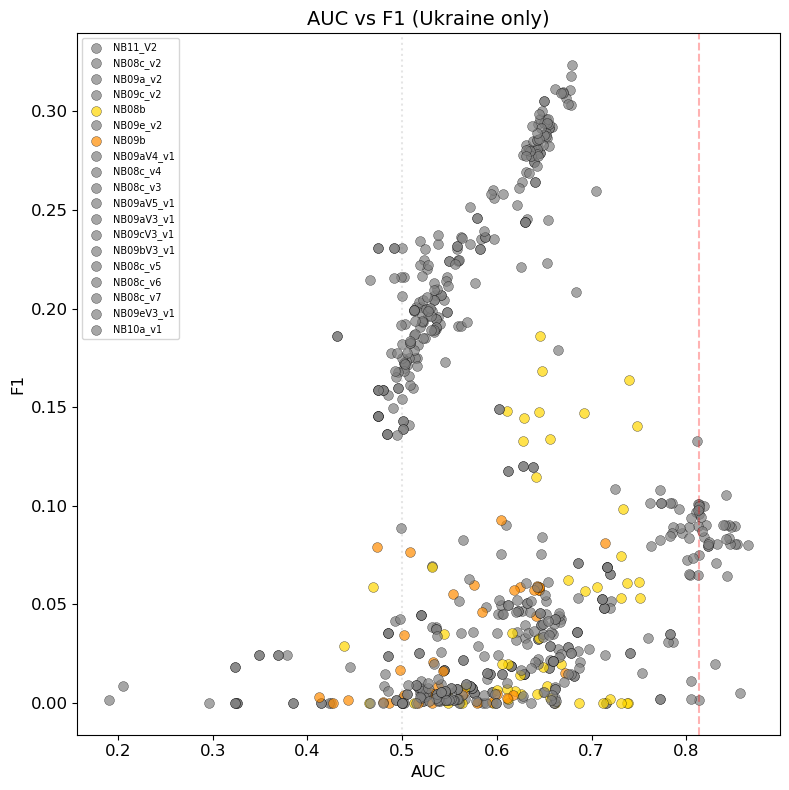

  Plot: auc_vs_f1_scatter.png


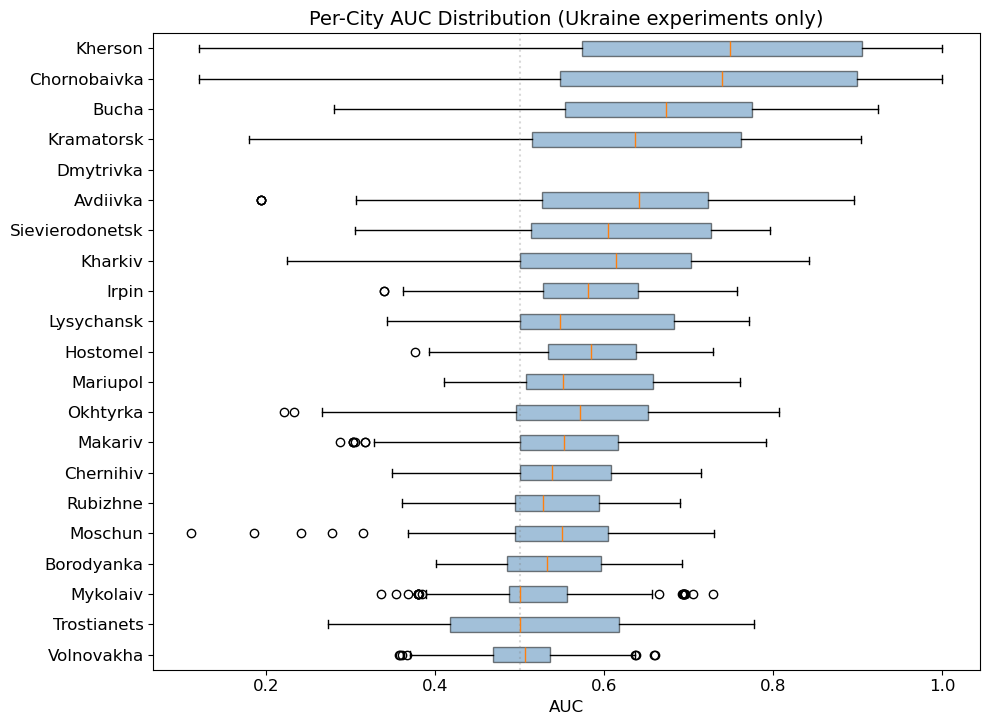

  Plot: per_city_auc_boxplot.png


In [9]:
# @title CELL 8: COMPARISON PLOTS (Ukraine only)
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 8: COMPARISON PLOTS (Ukraine only)")
print("=" * 70)

def save_fig(fig, name, dpi=150):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print(f"  Plot: {path.name}")

if len(EXPERIMENTS_DF) == 0:
    print("  No experiments to plot.")
else:
    df_plot = EXPERIMENTS_DF[
        (EXPERIMENTS_DF["auc"].notna()) & (~EXPERIMENTS_DF["is_xbd"])
    ].copy()
    non_ref = df_plot[~df_plot["is_reference"].fillna(False).astype(bool)].copy()

    nb_colors = {
        "reference": "red", "NB06": "gray", "NB07": "dimgray",
        "NB08a": "goldenrod", "NB08b": "gold",
        "NB09a": "steelblue", "NB09b": "darkorange",
        "NB09c": "forestgreen", "NB09d": "purple", "NB09e": "brown",
        "NB10": "teal", "NB11": "navy",
    }

    # --- PLOT 1: ALL EXPERIMENTS HORIZONTAL BAR ---
    if len(df_plot) > 0:
        df_bar = df_plot.sort_values("auc", ascending=True).tail(40)
        colors = [nb_colors.get(str(nb), "gray") for nb in df_bar["notebook"]]
        fig, ax = plt.subplots(figsize=(12, max(4, len(df_bar) * 0.28)))
        ax.barh(range(len(df_bar)), df_bar["auc"].values, color=colors, edgecolor="black", linewidth=0.3)
        ax.set_yticks(range(len(df_bar)))
        labels = [f"{r['experiment_name'][:35]} [{r['notebook']}|{str(r['parquet_name'])[:15]}]" for _, r in df_bar.iterrows()]
        ax.set_yticklabels(labels, fontsize=6, fontfamily="monospace")
        ax.set_xlabel("AUC")
        ax.set_xlim(0.2, 1.0)
        ax.axvline(0.813, color="red", linestyle="--", alpha=0.5, label="Dietrich=0.813")
        ax.axvline(0.5, color="gray", linestyle=":", alpha=0.3, label="Random=0.5")
        # add xBD ceiling line if available
        xbd_best_auc = EXPERIMENTS_DF.loc[EXPERIMENTS_DF["is_xbd"], "auc"].max()
        if pd.notna(xbd_best_auc):
            ax.axvline(xbd_best_auc, color="purple", linestyle="--", alpha=0.4,
                       label=f"xBD ceiling={xbd_best_auc:.3f}")
        ax.legend(fontsize=7)
        ax.set_title("Ukraine Experiments AUC (top 40)")
        fig.tight_layout()
        save_fig(fig, "ua_experiments_auc_bar")

    # --- PLOT 2: PARQUET x CLASSIFIER HEATMAP ---
    if len(non_ref) > 5 and non_ref["parquet_name"].nunique() > 1:
        pivot = non_ref.pivot_table(values="auc", index="parquet_name",
                                     columns="classifier_name", aggfunc="max")
        if pivot.shape[0] > 1 and pivot.shape[1] > 1:
            fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1]*1.2), max(3, pivot.shape[0]*0.5)))
            im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=0.4, vmax=0.85)
            ax.set_xticks(range(pivot.shape[1]))
            ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
            ax.set_yticks(range(pivot.shape[0]))
            ax.set_yticklabels(pivot.index, fontsize=8)
            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    val = pivot.values[i, j]
                    if not np.isnan(val):
                        ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7,
                                color="white" if val < 0.55 else "black")
            plt.colorbar(im, ax=ax, label="AUC")
            ax.set_title("Parquet x Classifier AUC (max, Ukraine only)")
            fig.tight_layout()
            save_fig(fig, "parquet_classifier_heatmap")

    # --- PLOT 3: AUC vs F1 SCATTER ---
    df_scatter = non_ref[non_ref["f1"].notna() & non_ref["auc"].notna()].copy()
    if len(df_scatter) > 3:
        fig, ax = plt.subplots(figsize=(8, 8))
        for nb in df_scatter["notebook"].unique():
            nb_sub = df_scatter[df_scatter["notebook"] == nb]
            ax.scatter(nb_sub["auc"], nb_sub["f1"], label=nb,
                      color=nb_colors.get(nb, "gray"), s=50, edgecolors="black", linewidth=0.3, alpha=0.7)
        ax.set_xlabel("AUC")
        ax.set_ylabel("F1")
        ax.axvline(0.813, color="red", linestyle="--", alpha=0.3)
        ax.axvline(0.5, color="gray", linestyle=":", alpha=0.2)
        ax.legend(fontsize=7)
        ax.set_title("AUC vs F1 (Ukraine only)")
        fig.tight_layout()
        save_fig(fig, "auc_vs_f1_scatter")

    # --- PLOT 4: PER-CITY AUC BOXPLOT ---
    ua_per_city_plot = PER_CITY_DF[~PER_CITY_DF.get("is_xbd", False)].copy() if "is_xbd" in PER_CITY_DF.columns else PER_CITY_DF.copy()
    if len(ua_per_city_plot) > 0 and "auc" in ua_per_city_plot.columns:
        city_aucs = ua_per_city_plot.groupby("city")["auc"].apply(list).to_dict()
        if len(city_aucs) > 1:
            cities_sorted = sorted(city_aucs.keys(), key=lambda c: np.nanmean(city_aucs[c]))
            fig, ax = plt.subplots(figsize=(10, max(3, len(cities_sorted)*0.35)))
            box_data = [city_aucs[c] for c in cities_sorted]
            bp = ax.boxplot(box_data, labels=cities_sorted, vert=False, patch_artist=True)
            for patch in bp["boxes"]:
                patch.set_facecolor("steelblue")
                patch.set_alpha(0.5)
            ax.axvline(0.5, color="gray", linestyle=":", alpha=0.3)
            ax.set_xlabel("AUC")
            ax.set_title("Per-City AUC Distribution (Ukraine experiments only)")
            fig.tight_layout()
            save_fig(fig, "per_city_auc_boxplot")


In [10]:
# @title CELL 9: REGRESSION DETECTIVE (compare runs over time)

print("=" * 70)
print("CELL 9: REGRESSION DETECTIVE")
print("=" * 70)

# load ALL runs (not just latest per notebook)
all_exp_hist, _ = ResultRegistry.load_all_runs(RESULTS_ROOT)
if not all_exp_hist:
    print("  No historical runs found.")
else:
    hist_df = ResultRegistry.experiments_to_dataframe(all_exp_hist)
    hist_df = hist_df[~hist_df['is_reference'].fillna(False).astype(bool)].copy()


    if 'timestamp' in hist_df.columns and len(hist_df) > 0:
        hist_df['ts'] = pd.to_datetime(hist_df['timestamp'], errors='coerce')
        hist_df = hist_df.sort_values('ts')

        print(f"  {len(hist_df)} experiment records across {hist_df['run_id'].nunique()} runs")
        print(f"  Date range: {hist_df['ts'].min()} to {hist_df['ts'].max()}")

        # per run_id: show best AUC
        print(f"\n  Best AUC per run (chronological):")
        print(f"  {'run_id':20s} {'notebook':10s} {'best_experiment':45s} {'AUC':>7s} {'n_exp':>6s}")
        print(f"  {'-'*95}")
        for run_id in hist_df['run_id'].unique():
            run_df = hist_df[hist_df['run_id'] == run_id]
            if run_df['auc'].notna().any():
                best = run_df.loc[run_df['auc'].idxmax()]
                print(f"  {run_id:20s} {best['notebook']:10s} {best['experiment_name']:45s} "
                      f"{best['auc']:7.4f} {len(run_df):>6d}")

        # detect regressions: same experiment_name, different runs, AUC dropped
        print(f"\n  REGRESSION CHECK (same experiment, AUC dropped between runs):")
        for exp_name in hist_df['experiment_name'].unique():
            exp_runs = hist_df[hist_df['experiment_name'] == exp_name].sort_values('ts')
            if len(exp_runs) < 2:
                continue
            aucs = exp_runs['auc'].dropna().values
            if len(aucs) < 2:
                continue
            if aucs[-1] < aucs[0] - 0.01:  # >1% drop
                print(f"    {exp_name:45s}: {aucs[0]:.4f} -> {aucs[-1]:.4f} (delta={aucs[-1]-aucs[0]:+.4f})")

CELL 9: REGRESSION DETECTIVE
  1071 experiment records across 31 runs
  Date range: 2026-04-23 00:33:00.008692 to 2026-07-03 08:35:31.306864

  Best AUC per run (chronological):
  run_id               notebook   best_experiment                                   AUC  n_exp
  -----------------------------------------------------------------------------------------------
  20260423_002416      NB08c_v2   C_F3_fusion_card_cohdrop                       0.8592     30
  20260423_071830      NB08c_v2   C_F3_fusion_card_cohdrop                       0.8592     30
  20260424_062449      NB08b      BDA__RGB+CARD__LogReg                          0.7506     72
  20260424_062508      NB08c_v2   C_F3_fusion_card_cohdrop                       0.8592     30
  20260425_003055      NB09d      xbd_on_xbd                                     0.9643     14
  20260425_003200      NB09e_v2   L4b_accumulator_s2__date_first_exceedance_mean  0.7137     21
  20260426_182134      NB08c_v2   C_F3_fusion_card_cohdrop

In [11]:
# @title CELL 10: GAP ANALYSIS
print("=" * 70)
print("CELL 10: GAP ANALYSIS")
print("=" * 70)
gaps = []

# check registry directory
reg_dir = RESULTS_ROOT / 'registry'
if not reg_dir.exists() or not list(reg_dir.glob('*.json')):
    gaps.append({'notebook': 'ALL', 'issue': 'NO_REGISTRY',
                 'detail': 'Registry dir empty. No notebooks have bda_results integrated yet.',
                 'severity': 'CRITICAL', 'fix': 'Integrate bda_results.py into NB06-NB09 (see Cell 11)'})

# check which notebooks have registry files
expected_nbs = ['NB06', 'NB07', 'NB08a', 'NB08b', 'NB09a', 'NB09b', 'NB09c', 'NB09d', 'NB09e']
if reg_dir.exists():
    existing_nbs = set()
    for f in reg_dir.glob('*_experiments_*.json'):
        nb = f.stem.split('_experiments_')[0]
        existing_nbs.add(nb)
    for nb in expected_nbs:
        if nb not in existing_nbs:
            gaps.append({'notebook': nb, 'issue': 'NOT_REGISTERED',
                         'detail': f'{nb} has no registry entries',
                         'severity': 'HIGH', 'fix': f'Add bda_results to {nb} and rerun'})

# check for below-random experiments
if len(EXPERIMENTS_DF) > 0:
    below_random = EXPERIMENTS_DF[
        (EXPERIMENTS_DF['auc'] < 0.50) &
        (EXPERIMENTS_DF['auc'].notna()) &
        (~EXPERIMENTS_DF['is_reference'].fillna(False).astype(bool))
    ]
    for _, row in below_random.iterrows():
        gaps.append({'notebook': row['notebook'], 'issue': 'BELOW_RANDOM',
                     'detail': f"{row['experiment_name']}: AUC={row['auc']:.4f} on {row['parquet_name']}",
                     'severity': 'CRITICAL', 'fix': 'Data pipeline bug or assessment NaN collapse. Check parquet features and NaN rates.'})

# known bugs -- only those NOT YET FIXED
gaps.append({'notebook': 'NB09d', 'issue': 'DONE',
             'detail': 'Post-battle MS composite bug fixed (v25). Patches now single-scene RGB from NB03e P7, not 3-year median.',
             'severity': 'INFO', 'fix': 'N/A. xBD-on-xBD AUC=0.876 valid. BDA DL experiments need rerun on single-scene patches.'})

gaps.append({'notebook': 'NB07', 'issue': 'DONE',
             'detail': 'Dietrich-28 assessment NaN fixed. min_obs reduced 3->2 in NB03e v37 P1/P1b/P1c. T0 cities had only 2 assessment CARD scenes.',
             'severity': 'INFO', 'fix': 'N/A. Rerun NB03e -> NB05b -> NB07 to propagate.'})

# pipeline status -- these are DONE, listed as INFO for completeness
gaps.append({'notebook': 'NB03d', 'issue': 'DONE',
             'detail': 'Plan-based audit/prune refactored. Wrong orbits, wrong dates, corrupt TIFs pruned. Data stack clean.',
             'severity': 'INFO', 'fix': 'N/A'})

gaps.append({'notebook': 'NB03e', 'issue': 'DONE',
             'detail': 'Plan-based derived products refactored. Composites, landuse, temporal stats, rolling windows, block stats.',
             'severity': 'INFO', 'fix': 'N/A'})

gaps.append({'notebook': 'NB03f', 'issue': 'DONE',
             'detail': 'Derived product audit/prune. Stale derived products from pre-plan era removed.',
             'severity': 'INFO', 'fix': 'N/A'})

gaps.append({'notebook': 'NB02a', 'issue': 'DONE',
             'detail': 'Pre-battle SLC pairs for ongoing-conflict cities now handled (v6). select_prebattle_baseline added.',
             'severity': 'INFO', 'fix': 'N/A. Note: Cell 0 markdown L101 still says BUG — update the header.'})

# future notebooks
for nb in ['NB10', 'NB11a', 'NB11b', 'NB11c', 'NB12']:
    gaps.append({'notebook': nb, 'issue': 'NOT_BUILT', 'detail': f'{nb} not yet created',
                 'severity': 'INFO', 'fix': 'Build notebook'})

GAPS_DF = pd.DataFrame(gaps)
if len(GAPS_DF) > 0:
    print(f"  {len(GAPS_DF)} issues:\n")
    for sev in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'INFO']:
        sev_df = GAPS_DF[GAPS_DF['severity'] == sev]
        if len(sev_df) > 0:
            print(f"  [{sev}] ({len(sev_df)} issues)")
            for _, row in sev_df.iterrows():
                print(f"    {row['notebook']:8s} | {row['issue']:18s} | {row['detail'][:80]}")
            print()

CELL 10: GAP ANALYSIS
  109 issues:

  [CRITICAL] (92 issues)
    NB09e_v2 | BELOW_RANDOM       | L4b_accumulator_s2__date_worst_swir_rise_mean: AUC=0.5000 on bda_ms_change_v2
    NB08c_v5 | BELOW_RANDOM       | C_A19_card_drop: AUC=0.4998 on bda_card_drop_v5
    NB08c_v5 | BELOW_RANDOM       | C_A14_coh_drop: AUC=0.4995 on bda_coh_drop_v5
    NB09d    | BELOW_RANDOM       | d8a_rgb_scratch: AUC=0.4994 on pixel_segmentation
    NB08c_v7 | BELOW_RANDOM       | C_A27_block_accum_card: AUC=0.4994 on bda_block_accum_card_v7
    NB09eV3_v1 | BELOW_RANDOM       | plausibility_standalone_plausibility_score: AUC=0.4990 on bda_plausibility_v2
    NB09eV3_v1 | BELOW_RANDOM       | L4b_accumulator_s2__mahalanobis_exceedance_count: AUC=0.4989 on bda_ms_maha_v2
    NB09cV3_v1 | BELOW_RANDOM       | E7b_GaussianNB: AUC=0.4983 on bda_fusion_composite_blockstats_v3
    NB09aV5_v1 | BELOW_RANDOM       | R3b_coh_only: AUC=0.4977 on bda_fusion_composite_blockstats_v2
    NB09b    | BELOW_RANDOM       | B

## CELL 11: How to integrate `bda_results.py` into existing notebooks

### Step 1: Add to CELL S0 (after global_setup)

```python
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09a')
```

### Step 2: After each experiment cell (e.g. after evaluate_groupkfold)

```python
# existing code:
result = evaluate_groupkfold(rf, X, y, groups, "R0_dietrich28_groupkfold")

# add this:
if result:
    registry.log_experiment(
        cell_id='cell_r0',
        experiment_name='R0_dietrich28_groupkfold',
        parquet_name='bda_product_prepost',
        parquet_fmt=str(PARQUET_PREPOST_TIER_FMT),
        tier_selection=TIER_SELECTION,
        classifier_name='RF-200',
        classifier_params=RF_PARAMS,
        feature_set_name='dietrich28',
        feature_cols=clean,
        cv_method='GroupKFold',
        n_folds=N_FOLDS,
        imputation='median',
        y_true=result['y_true'],
        y_proba=result['y_proba'],
        groups=result['groups'],
        fold_metrics=compute_fold_metrics(result.get('fold_results', [])),
        note='Dietrich 2025 replication',
    )
```

### Step 3: Profile datasets (once per parquet, in S0 or first data cell)

```python
registry.log_dataset_profile(
    parquet_name='bda_product_prepost',
    parquet_fmt=str(PARQUET_PREPOST_TIER_FMT),
    tier_selection=TIER_SELECTION,
    df=df,               # the loaded DataFrame
    feature_cols=FEATURE_COLS,
    meta_cols=META_COLS,
)
```

### Step 4: Save at end of notebook

```python
registry.save()
```

### Step 5: Add paper references (in NB11d or any notebook)

```python
registry.log_reference('Dietrich_2025', auc=0.813, f1=0.749,
                        precision=0.671, recall=0.846, n_features=28,
                        paper='Dietrich et al. 2025', note='GEE RF, geographic split')
registry.log_reference('Ballinger_2024_PWTT', auc=0.87, n_features=1,
                        paper='Ballinger 2024', note='unsupervised PWTT')
```

### What you get automatically per experiment:
- 25+ metrics (AUC, F1, precision, recall, MCC, balanced_accuracy, avg_precision, brier, log_loss, specificity, TP/FP/TN/FN, precision@recall_80/90/95)
- Per-city breakdown of all metrics
- Full provenance (parquet, tier, cities, features, classifier params, CV method, imputation, timestamp)
- Fold-level metrics (AUC mean/std/min/max per fold)
- Feature statistics (if log_dataset_profile called)

In [12]:
# @title CELL 12: SAVE CONSOLIDATED REPORT

print("=" * 70)
print("CELL 12: SAVE REPORT")
print("=" * 70)

ts = _dt.now().strftime('%Y%m%d_%H%M%S')

if len(EXPERIMENTS_DF) > 0:
    path = OUT_DIR / f"consolidated_experiments_{ts}.csv"
    EXPERIMENTS_DF.to_csv(path, index=False)
    print(f"  Saved: {path.name} ({len(EXPERIMENTS_DF)} experiments)")

if len(PROFILES_DF) > 0:
    path = OUT_DIR / f"dataset_profiles_{ts}.csv"
    PROFILES_DF.to_csv(path, index=False)
    print(f"  Saved: {path.name}")

if len(FEATURE_STATS_DF) > 0:
    path = OUT_DIR / f"feature_stats_{ts}.csv"
    FEATURE_STATS_DF.to_csv(path, index=False)
    print(f"  Saved: {path.name} ({len(FEATURE_STATS_DF)} features)")

if len(PER_CITY_DF) > 0:
    path = OUT_DIR / f"per_city_metrics_{ts}.csv"
    PER_CITY_DF.to_csv(path, index=False)
    print(f"  Saved: {path.name} ({len(PER_CITY_DF)} city-experiment pairs)")

if len(GAPS_DF) > 0:
    path = OUT_DIR / f"gap_analysis_{ts}.csv"
    GAPS_DF.to_csv(path, index=False)
    print(f"  Saved: {path.name}")

# full report JSON
report = {
    'generated': _dt.now().isoformat(),
    'tier_selection': TIER_SELECTION,
    'n_experiments': len(EXPERIMENTS_DF),
    'n_profiles': len(PROFILES_DF),
    'n_gaps': len(GAPS_DF),
}
if len(EXPERIMENTS_DF) > 0 and EXPERIMENTS_DF['auc'].notna().any():
    best = EXPERIMENTS_DF.loc[EXPERIMENTS_DF['auc'].idxmax()]
    report['best_overall'] = {
        'experiment': str(best['experiment_name']),
        'notebook': str(best['notebook']),
        'auc': float(best['auc']),
        'parquet': str(best['parquet_name']),
        'classifier': str(best['classifier_name']),
        'features': str(best['feature_set_name']),
    }
path = OUT_DIR / f"nb11d_report_{ts}.json"
with open(path, 'w') as f:
    _json.dump(report, f, indent=2, default=str)
print(f"  Saved: {path.name}")

print(f"\n  All outputs in: {OUT_DIR}")

CELL 12: SAVE REPORT
  Saved: consolidated_experiments_20260703_084619.csv (768 experiments)
  Saved: per_city_metrics_20260703_084619.csv (12379 city-experiment pairs)
  Saved: gap_analysis_20260703_084619.csv
  Saved: nb11d_report_20260703_084619.json

  All outputs in: /content/drive_f/masterthesis/results/nb11d
